# 01 — Data Preprocessing

This notebook covers the full preprocessing pipeline:

1. **Loading & cleaning** — normalize column names, drop columns with too many missing values
2. **VIF pruning** — remove multicollinear features
3. **Correlation-based pruning** — use GMM clustering on Pearson correlation to remove features highly correlated with the target

Outputs saved to `output_datasets/`:
- `data_clean1.csv` — after basic cleaning
- `data_clean2.csv` — after VIF pruning
- `data_clean3.csv` — after correlation pruning (input for anomaly detection)

## 0. Imports & configuration

In [ ]:
import numpy as np
import pandas as pd

from data_lab.preprocessing_functions import norm_cols, clean_numeric, keep_meta
from data_lab.preprocessing_functions import vif_prune
from data_lab.preprocessing_functions import best_gmm_by_bic, bic_grid
from data_lab.plot_functions import plot_bic_and_clusters, plot_feature_scatter

from data_lab.config import (
    DATA_PATH, OUT_DATASETS,
    TARGET, META_COLS,
    MISSING_MAX, VIF_MAX,
    EVAL_WINDOW, BIC_ITERATIONS,
    RANDOM_STATE,
)

/Users/gixs/Project/SafeAI/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
OUT_DATASETS.mkdir(parents=True, exist_ok=True)

## 1. Load data

In [3]:
df = norm_cols(pd.read_csv(DATA_PATH, encoding="ISO-8859-1", low_memory=False))
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded: 7220 rows, 537 columns


,uuid,filename,test,limitation,throughputlim,latencylim,packetlosslim,interface,counts,dl.throughput.value,...,rcvooopack.q90,sndwnd.min,sndwnd.max,sndwnd.mean,sndwnd.std,sndwnd.median,sndwnd.q10,sndwnd.q25,sndwnd.q75,sndwnd.q90
0,02ba0c6280d1_1762202749_00000000000025D4,WIFI_2025-11-10_02-00-11_UTC.txt,DL,NaN,NaN,NaN,NaN,wlp0s20f3,30,593.277440,...,0.0,1529728,1597440,1.563708e+06,18088.656058,1559296.0,1539225.6,1550144.0,1577984.0,1585395.2
1,b60f1e0a02e1_1762202749_00000000000002F0,WIFI_2025-11-07_20-11-10_UTC.txt,DL,NaN,NaN,NaN,NaN,wlp0s20f3,30,579.654536,...,0.0,1407232,1592064,1.553621e+06,38550.646416,1557248.0,1543091.2,1549952.0,1577984.0,1583846.4
2,4bf7dc088d31_1762202749_00000000000004FD,WIFI_2025-11-11_16-24-57_UTC.txt,DL,Throughput,20000kbit,NaN,NaN,wlp0s20f3,22,18.040134,...,0.0,65152,413952,3.631244e+05,78861.850698,413952.0,328576.0,328576.0,413952.0,413952.0
3,02ba0c6280d1_1762202749_000000000000040B,WIFI_2025-11-10_07-53-54_UTC.txt,DL,NaN,NaN,NaN,NaN,wlp0s20f3,38,584.629354,...,0.0,1527680,1597440,1.568141e+06,17803.974398,1566848.0,1548953.6,1557248.0,1580576.0,1596160.0
4,16ed801fb1e7_1762202749_00000000000019B9,WIFI_2025-11-15_09-17-48_UTC.txt,DL,Latency,NaN,500ms,NaN,wlp0s20f3,11,7.570025,...,0.0,41984,1592832,5.049949e+05,551237.456553,269184.0,51712.0,68992.0,839488.0,1264512.0


## 2. Basic cleaning

- Select numeric columns only
- Drop columns with more than `MISSING_MAX` fraction of missing values
- Keep metadata columns alongside

In [4]:
y    = df[TARGET]
X    = clean_numeric(df.select_dtypes("number"), missing_max=MISSING_MAX)
meta = df.select_dtypes("object")

print(f"Features after cleaning: {X.shape[1]}")

out1 = keep_meta(X, meta)
out1.to_csv(OUT_DATASETS / "data_clean1.csv", index=False)
print(f"Saved data_clean1.csv — {X.shape[1]} features")

Features after cleaning: 372


/var/folders/kb/qf9g_7353zb1y6s3k0v1fr8c0000gn/T/ipykernel_36645/3384595639.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  meta = df.select_dtypes("object")


Saved data_clean1.csv — 372 features


## 3. VIF pruning

Iteratively remove the feature with the highest Variance Inflation Factor until all features are below `VIF_MAX = 20.0`.
This reduces multicollinearity before clustering.

In [5]:
X2 = vif_prune(X, vif_max=VIF_MAX)

print(f"Features after VIF pruning: {X2.shape[1]} (removed {X.shape[1] - X2.shape[1]})")

out2 = keep_meta(pd.concat([X2, y.rename(TARGET)], axis=1), meta)
out2.to_csv(OUT_DATASETS / "data_clean2.csv", index=False)
print(f"Saved data_clean2.csv — {X2.shape[1]} features")

Features after VIF pruning: 133 (removed 239)
Saved data_clean2.csv — 133 features


## 4. Correlation-based pruning

Compute the Pearson correlation of each feature with the target.
Use a Monte Carlo GMM (BIC) to cluster the correlation vector and discard
the cluster closest to zero (features with low predictive value).

### 4.1 Compute correlation vector

In [6]:
out_num     = out2.select_dtypes("number")
corr_matrix = 1 - out_num.corr(method="pearson").abs()
corr_vector = corr_matrix[TARGET].to_numpy().reshape(-1, 1)

print(f"Correlation vector shape: {corr_vector.shape}")

Correlation vector shape: (134, 1)


### 4.2 Monte Carlo BIC — estimate optimal number of clusters

In [7]:
max_num_clusters = np.min([EVAL_WINDOW + 1, len(corr_vector)])

bic_ite, seeds = bic_grid(
    corr_vector,
    max_k=max_num_clusters,
    iterations=BIC_ITERATIONS,
    seed=RANDOM_STATE,
)

num_opt_clusters_bic = np.argmin(np.mean(bic_ite, axis=0)) + 1
print(f"Optimal number of clusters (BIC): {num_opt_clusters_bic}")

Optimal number of clusters (BIC): 3


### 4.3 Fit best GMM and assign clusters

In [8]:
best         = best_gmm_by_bic(corr_vector, k=num_opt_clusters_bic, seeds=seeds[:, num_opt_clusters_bic - 1])
clusters_bic = best.predict(corr_vector)
centroids_bic = best.means_

### 4.4 Remove low-correlation cluster

In [9]:
out3 = out_num.copy()

if len(np.unique(clusters_bic)) > 1:
    keep_mask = clusters_bic != np.argmin(centroids_bic)
    out3 = out3.loc[:, out3.columns[keep_mask]]
    print(f"Removed {keep_mask.sum()} low-correlation features")

out3[TARGET] = y
out3 = keep_meta(out3, meta)
out3.to_csv(OUT_DATASETS / "data_clean3.csv", index=False)
print(f"Saved data_clean3.csv — {out3.shape[1]} total columns")

Removed 118 low-correlation features
Saved data_clean3.csv — 123 total columns


## 5. Visualizations

### 5.1 BIC curve & GMM cluster assignments

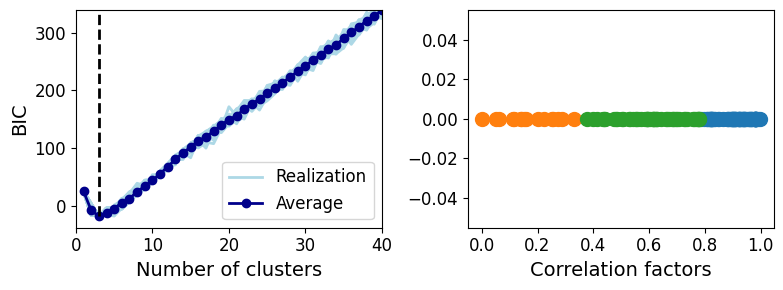

In [10]:
plot_bic_and_clusters(
    bic_ite,
    BIC_ITERATIONS,
    max_num_clusters,
    num_opt_clusters_bic,
    corr_vector,
    clusters_bic,
)

### 5.2 Scatter plots — removed features vs target

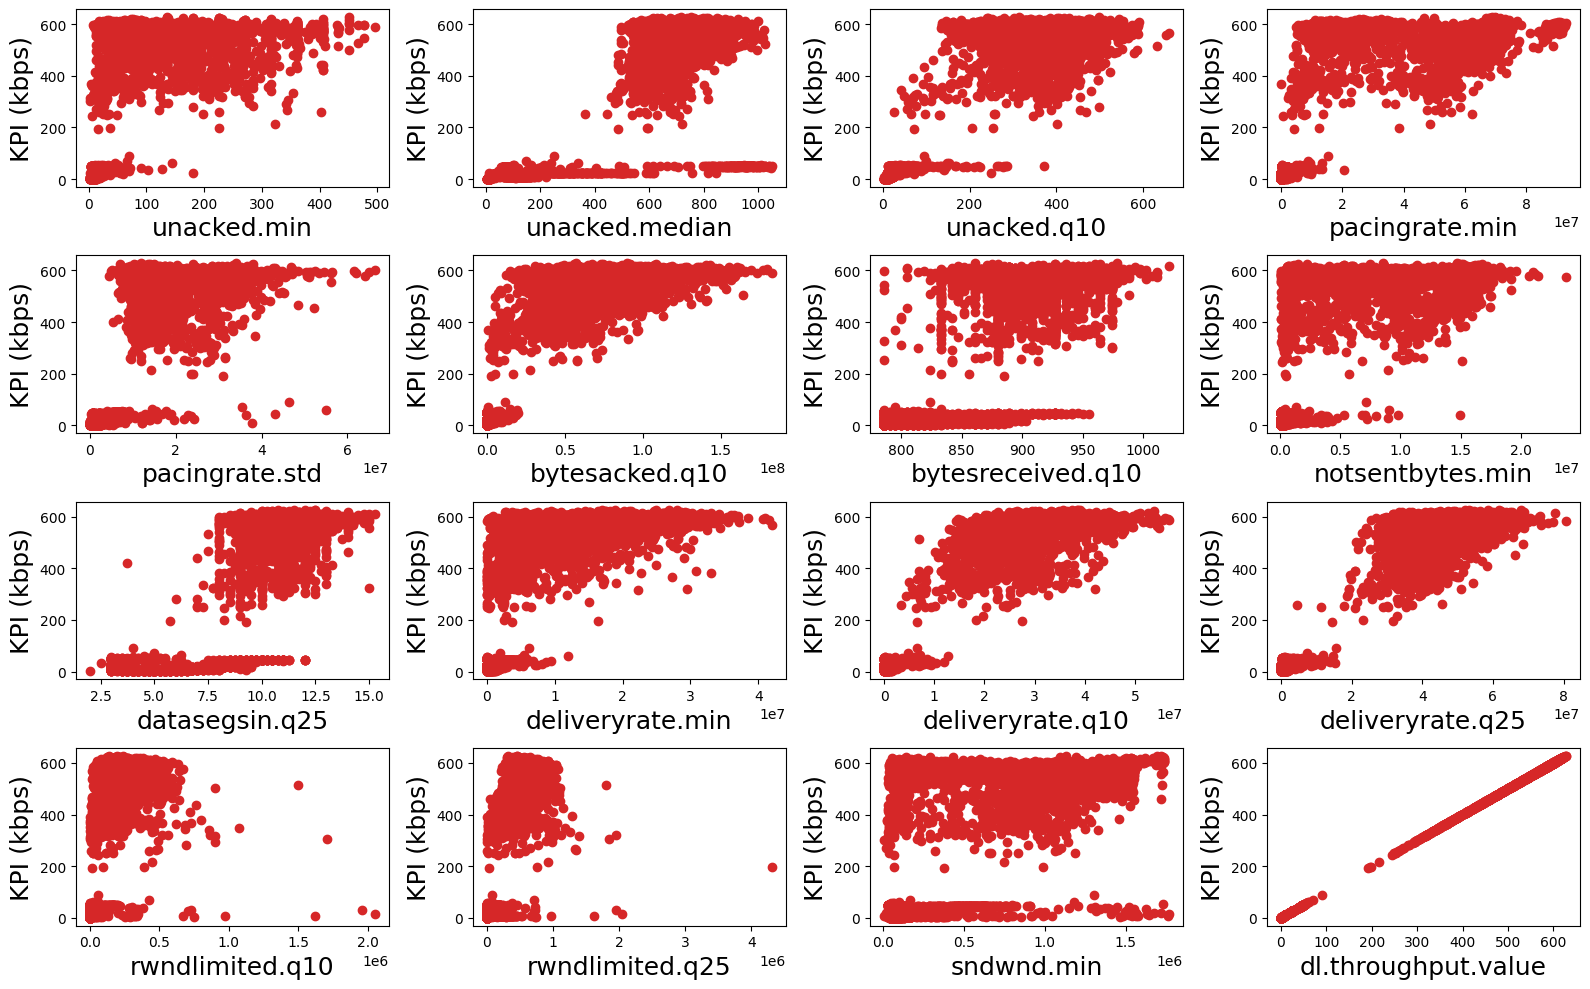

In [11]:
columns_to_remove = out_num.columns[clusters_bic == np.argmin(centroids_bic)]
plot_feature_scatter(out_num, TARGET, columns_to_remove, ncols=4)